# SEIRS-SEI Malaria Model

ODE approximation of SEIRS-SEI DDE model with yearly population from IBGE data, based on the results of 
### data_files/notebooks/Biting_Rate_Estimation.ipynb ###

From this file, we have $T'=16^\circ C, \ D_1=24.8$ and $m$, which we assume to be equal to $M_0$ in this case, is $10N_0$

We also use the fitted values of $E_{H0}, R_{H0}$ and $I_{M0}$, obtained from
### SEIRS_SEI_ODE_IC_Calibration.ipynb ###

In [2]:
from seirs_sei_ode_shared import *
%matplotlib inline

Data loaded and filtered successfully!
Climate data: 2556 days
Cases data: 2556 days
Pop data: 2556 days
Deforestation data: 3288 days
Forest fires data: 3288 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
The initial ratio of exposed to infected mosquitos was estimated to be ~3
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=80342, E_M=2511, I_M=837


In [3]:
#### Updating initial conditions:

rural_cases_df = cases_data.copy()
cols = [
    "active_total",
    "active_symptomatic",
    "active_asymptomatic",
    "new_cases",
    "cumulative_cases",
    "active_per_new_case",
]
rural_cases_df[cols] = rural_cases_df[cols] * (41.54 / 100)
I_H0 = round(rural_cases_df["active_total"].iloc[0])
N_2017 = round(pop_by_year[2017])

E_H0 = 418 #round(N_2017 * 0.05)
R_H0 = 418 #round(N_2017 * 0.05)
S_H0 = N_2017 - E_H0 - I_H0 - R_H0

M_0 = 10 * N_2017
I_M0 = 1674 #round(M_0 * 0.02)
E_M0 = round(I_M0 * 3)
S_M0 = M_0 - E_M0 - I_M0
initial_state_2017 = np.array([S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0])

print(
    f"Initial human compartments in 2017: N={N_2017}, S_H={S_H0}, E_H={E_H0}, I_H={I_H0}, R_H={R_H0}"
)
print(
    f"Initial mosquito compartments in 2017: M={M_0}, S_M={S_M0}, E_M={E_M0}, I_M={I_M0}"
)

Initial human compartments in 2017: N=8369, S_H=6589, E_H=418, I_H=944, R_H=418
Initial mosquito compartments in 2017: M=83690, S_M=76994, E_M=5022, I_M=1674


In [4]:
#### Yearly Simulation (2017-2023)
years = list(range(2017, 2024))
all_results = []
current_state = initial_state_2017.copy()

USE_SMOOTH_CLIMATE = False

for year in years:
    print(f"\nSimulating {year}...")
    N = round(pop_by_year[year])
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
    if USE_SMOOTH_CLIMATE:
        year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    num_days = len(year_climate)
    print(f"Year {year}: N={N}, Days={num_days}")
    
    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                            c1, c2, D1, b1, b2, A, B, C, DD, 
                            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                            gamma, R_L, M_prime, tau_H, omega,
                            M_min, permanent_factor, use_smooth_climate=USE_SMOOTH_CLIMATE)
    
    sol = solve_ivp(ode_func, [0, num_days], current_state, 
                    t_eval=np.linspace(0, num_days, num_days*10), method='LSODA') #'DOP853')
    
    all_results.append({'year': year, 'N': N, 'sol': sol, 'climate': year_climate})
    current_state = sol.y[:, -1].copy()
    print(f"Finished {year}. Final I_H: {round(current_state[2])}, Final I_M: {round(current_state[6])}")

print("\nAll years simulated successfully!")


Simulating 2017...
Year 2017: N=8369, Days=365
Finished 2017. Final I_H: 167, Final I_M: 26

Simulating 2018...
Year 2018: N=8260, Days=365
Finished 2018. Final I_H: 17, Final I_M: 1

Simulating 2019...
Year 2019: N=8153, Days=365
Finished 2019. Final I_H: 2, Final I_M: 0

Simulating 2020...
Year 2020: N=8045, Days=366
Finished 2020. Final I_H: 0, Final I_M: 0

Simulating 2021...
Year 2021: N=7939, Days=365
Finished 2021. Final I_H: 0, Final I_M: 0

Simulating 2022...
Year 2022: N=7832, Days=365
Finished 2022. Final I_H: 0, Final I_M: 0

Simulating 2023...
Year 2023: N=7942, Days=365
Finished 2023. Final I_H: 0, Final I_M: 0

All years simulated successfully!


In [5]:
def run_simulation_with_M(M_prime, initial_state=None):
    if initial_state is None:
        init_state = initial_state_2017.copy()
    else:
        init_state = initial_state.copy()
    all_IH = []
    all_dates = []
    current_state = init_state
    for year in years:
        N = round(pop_by_year[year])
        start = f"{year}-01-01"
        end = f"{year}-12-31"
        year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
        if USE_SMOOTH_CLIMATE:
            year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        num_days = len(year_climate)
        def ode_func(t, z):
            return seirs_sei_ode(t, z, N, year_climate,
                                T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                                c1, c2, D1, b1, b2, A, B, C, DD,
                                Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                                optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                                gamma, R_L, M_prime, tau_H, omega,
                                M_min=M_min, permanent_factor=permanent_factor, use_smooth_climate=USE_SMOOTH_CLIMATE)
        sol = solve_ivp(ode_func, [0, num_days], current_state,
                        t_eval=np.linspace(0, num_days, num_days*10), method='LSODA')
        if not sol.success:
            return np.array([]), np.array([])
        current_state = sol.y[:, -1].copy()
        current_state = np.maximum(current_state, 0)
        t_interp = np.linspace(0, sol.t[-1], len(year_climate))
        IH_interp = interp1d(sol.t, sol.y[2])(t_interp)
        all_IH.extend(IH_interp)
        all_dates.extend(year_climate['date'].values)
    return np.array(all_dates), np.array(all_IH)

In [6]:
def objective_function(log_M_prime):
    M_prime = np.exp(log_M_prime)
    # Use smoothed climate values to match ODE's carrying capacity calculation
    T0_smooth = climate_data['temp_med_smooth'].iloc[0]
    R0_smooth = climate_data['precip_med_smooth'].iloc[0]
    f_T_0 = temp_factor_briere_normalized_anop(T0_smooth)
    habitat_creating_factor_0 = 2*R0_smooth/R_L
    habitat_flushing_factor_0 = np.exp(1 - (2*R0_smooth/R_L))
    f_R_0 = habitat_creating_factor_0 * habitat_flushing_factor_0
    K_0 = M_prime * f_T_0 * f_R_0
    if M_0 > K_0:
        return 1e15
    dates, IH = run_simulation_with_M(M_prime)
    if len(dates) == 0:
        return 1e15
    model_interp = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    obs_dates_int = rural_cases_df['date'].astype(np.int64).values
    model_at_obs = model_interp(obs_dates_int)
    observed = rural_cases_df['active_total'].values
    mse = np.mean((model_at_obs - observed) ** 2)
    return mse

In [7]:
print("Grid search for M'...")
multipliers = [10, 20, 30, 40, 50, 60, 75] #[10, 20, 30, 50, 75, 100, 150, 200, 300, 500] #Reduces ranges of multiplier for faster solving
grid_results = []
for mult in multipliers:
    M_prime_test = mult * N_2017
    log_mp = np.log(M_prime_test)
    mse = objective_function(log_mp)
    grid_results.append((M_prime_test, mult, mse))
    print(f"  M' = {mult:>4d} x N = {M_prime_test:>12,.0f} -> MSE = {mse:>15,.2f}")
grid_results.sort(key=lambda x: x[2])
best_mult = grid_results[0][1]
best_mse = grid_results[0][2]
print(f"\nBest from grid: M' = {best_mult} x N (MSE = {best_mse:,.2f})")

Grid search for M'...
  M' =   10 x N =       83,690 -> MSE = 1,000,000,000,000,000.00
  M' =   20 x N =      167,380 -> MSE =      517,391.70
  M' =   30 x N =      251,070 -> MSE =      469,469.05
  M' =   40 x N =      334,760 -> MSE =      400,970.23
  M' =   50 x N =      418,450 -> MSE =      316,578.29
  M' =   60 x N =      502,140 -> MSE =      312,162.38
  M' =   75 x N =      627,675 -> MSE =      517,235.56

Best from grid: M' = 60 x N (MSE = 312,162.38)


In [8]:
print("Fine optimization with minimize_scalar...")
log_low = np.log(best_mult * 0.3 * N_2017)
log_high = np.log(best_mult * 3.0 * N_2017)
result = minimize_scalar(
    objective_function,
    bounds=(log_low, log_high),
    method='bounded',
    options={'maxiter': 100, 'xatol': 0.01}
)
M_prime_optimal = np.exp(result.x)
optimal_multiplier = M_prime_optimal / N_2017
print(f"Optimal M' = {optimal_multiplier:.2f} x N = {M_prime_optimal:,.0f}")
print(f"Optimal MSE = {result.fun:,.2f}")

Fine optimization with minimize_scalar...
Optimal M' = 55.99 x N = 468,601
Optimal MSE = 295,312.38


Final simulation with optimal M'...


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


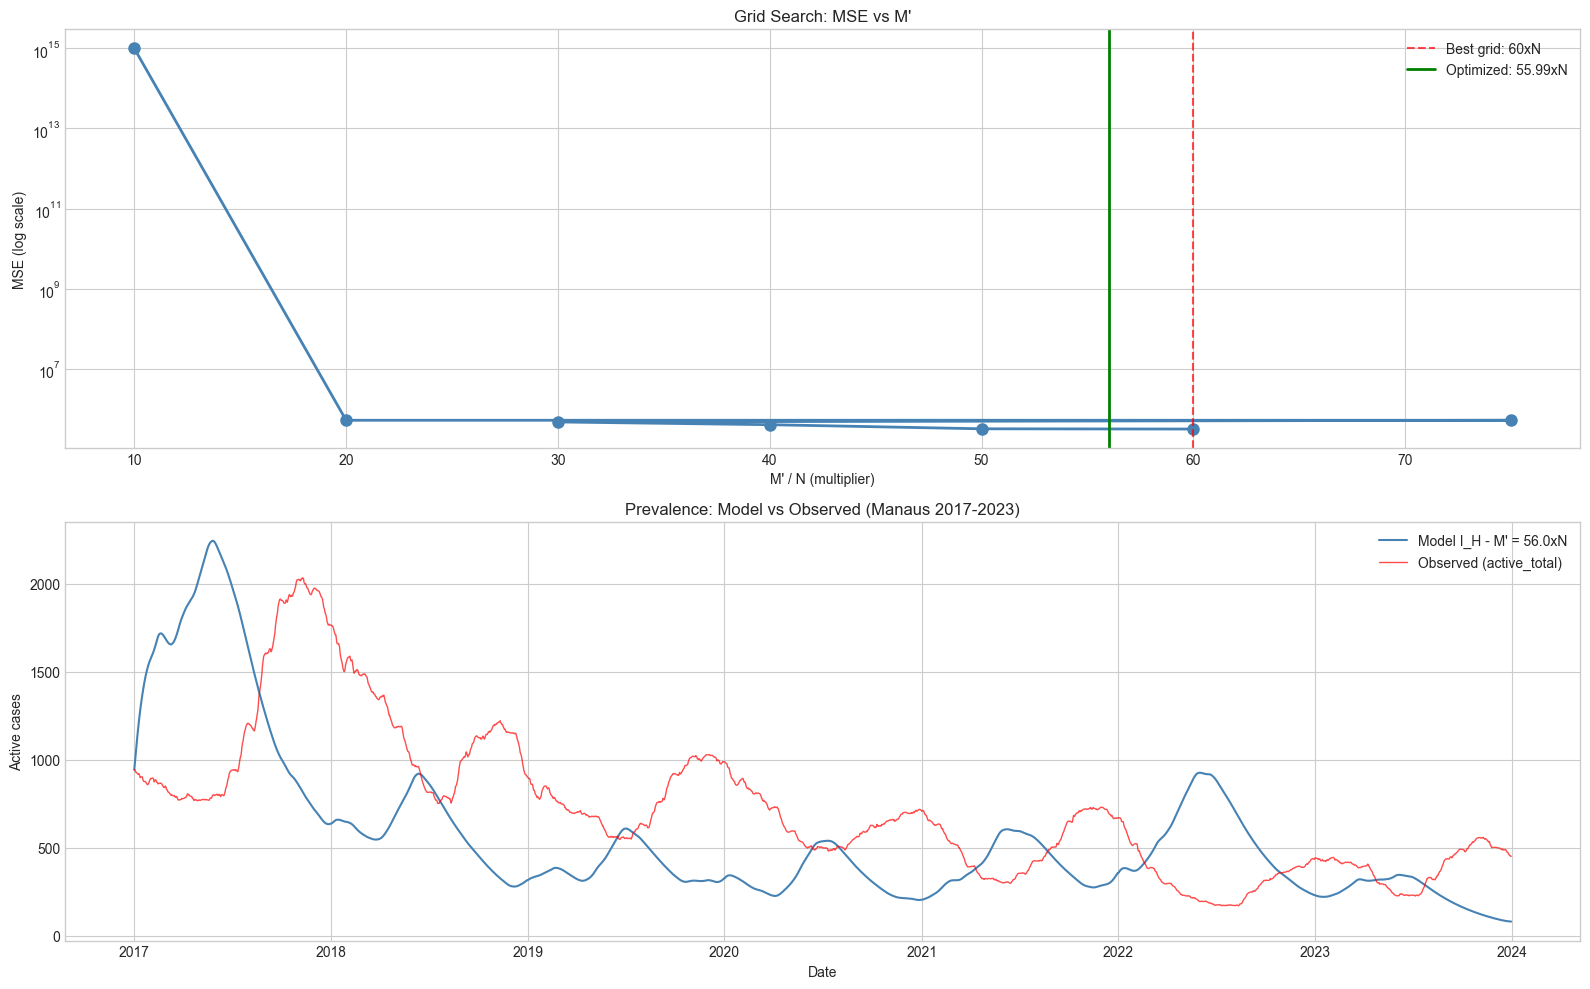


Calibration Summary
  Population N (2017):                8,369
  M_0 initial (9.9 x N):            83,690
  Optimal M':                      468,601
  Optimal M' / N:                    55.99
  Final MSE:                         295,312.38
  Final RMSE:                            543.43


In [9]:
print("Final simulation with optimal M'...")
dates_opt, IH_opt = run_simulation_with_M(M_prime_optimal)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax1 = axes[0]
mults = [r[1] for r in grid_results]
mses = [r[2] for r in grid_results]
ax1.semilogy(mults, mses, 'o-', color='steelblue', markersize=8, linewidth=2)
ax1.axvline(best_mult, color='red', linestyle='--', alpha=0.7, label=f'Best grid: {best_mult}xN')
ax1.axvline(optimal_multiplier, color='green', linestyle='-', linewidth=2,
            label=f"Optimized: {optimal_multiplier:.2f}xN")
ax1.set_xlabel("M' / N (multiplier)")
ax1.set_ylabel("MSE (log scale)")
ax1.set_title("Grid Search: MSE vs M'")
ax1.legend()

ax2 = axes[1]
ax2.plot(pd.to_datetime(dates_opt), IH_opt, color='steelblue',
         linewidth=1.5, label=f"Model I_H - M' = {optimal_multiplier:.1f}xN")
ax2.plot(rural_cases_df['date'], rural_cases_df['active_total'], color='red',
         linewidth=1.0, alpha=0.7, label='Observed (active_total)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Active cases')
ax2.set_title('Prevalence: Model vs Observed (Manaus 2017-2023)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nCalibration Summary")
print(f"  Population N (2017):           {N_2017:>10,}")
print(f"  M_0 initial (9.9 x N):        {M_0:>10,.0f}")
print(f"  Optimal M':                   {M_prime_optimal:>10,.0f}")
print(f"  Optimal M' / N:               {optimal_multiplier:>10.2f}")
print(f"  Final MSE:                    {result.fun:>15,.2f}")
print(f"  Final RMSE:                   {np.sqrt(result.fun):>15,.2f}")

In [10]:
#### Yearly Simulation (2017-2023)
years = list(range(2017, 2024))
all_results = []
current_state = initial_state_2017.copy()

for year in years:
    print(f"\nSimulating {year}...")
    N = round(pop_by_year[year])
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
    if USE_SMOOTH_CLIMATE:
        year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    num_days = len(year_climate)
    print(f"Year {year}: N={N}, Days={num_days}")
    
    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                            c1, c2, D1, b1, b2, A, B, C, DD, 
                            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                            gamma, R_L, M_prime_optimal, tau_H, omega,
                            M_min=M_min, permanent_factor=permanent_factor, use_smooth_climate=USE_SMOOTH_CLIMATE)
    
    sol = solve_ivp(ode_func, [0, num_days], current_state, 
                    t_eval=np.linspace(0, num_days, num_days*10), method='LSODA') #'DOP853')
    
    all_results.append({'year': year, 'N': N, 'sol': sol, 'climate': year_climate})
    current_state = sol.y[:, -1].copy()
    print(f"Finished {year}. Final I_H: {round(current_state[2])}, Final I_M: {round(current_state[6])}")

print("\nAll years simulated successfully!")


Simulating 2017...
Year 2017: N=8369, Days=365
Finished 2017. Final I_H: 637, Final I_M: 500

Simulating 2018...
Year 2018: N=8260, Days=365
Finished 2018. Final I_H: 316, Final I_M: 121

Simulating 2019...
Year 2019: N=8153, Days=365
Finished 2019. Final I_H: 325, Final I_M: 294

Simulating 2020...
Year 2020: N=8045, Days=366
Finished 2020. Final I_H: 205, Final I_M: 123

Simulating 2021...
Year 2021: N=7939, Days=365
Finished 2021. Final I_H: 357, Final I_M: 221

Simulating 2022...
Year 2022: N=7832, Days=365
Finished 2022. Final I_H: 231, Final I_M: 31

Simulating 2023...
Year 2023: N=7942, Days=365
Finished 2023. Final I_H: 81, Final I_M: 26

All years simulated successfully!


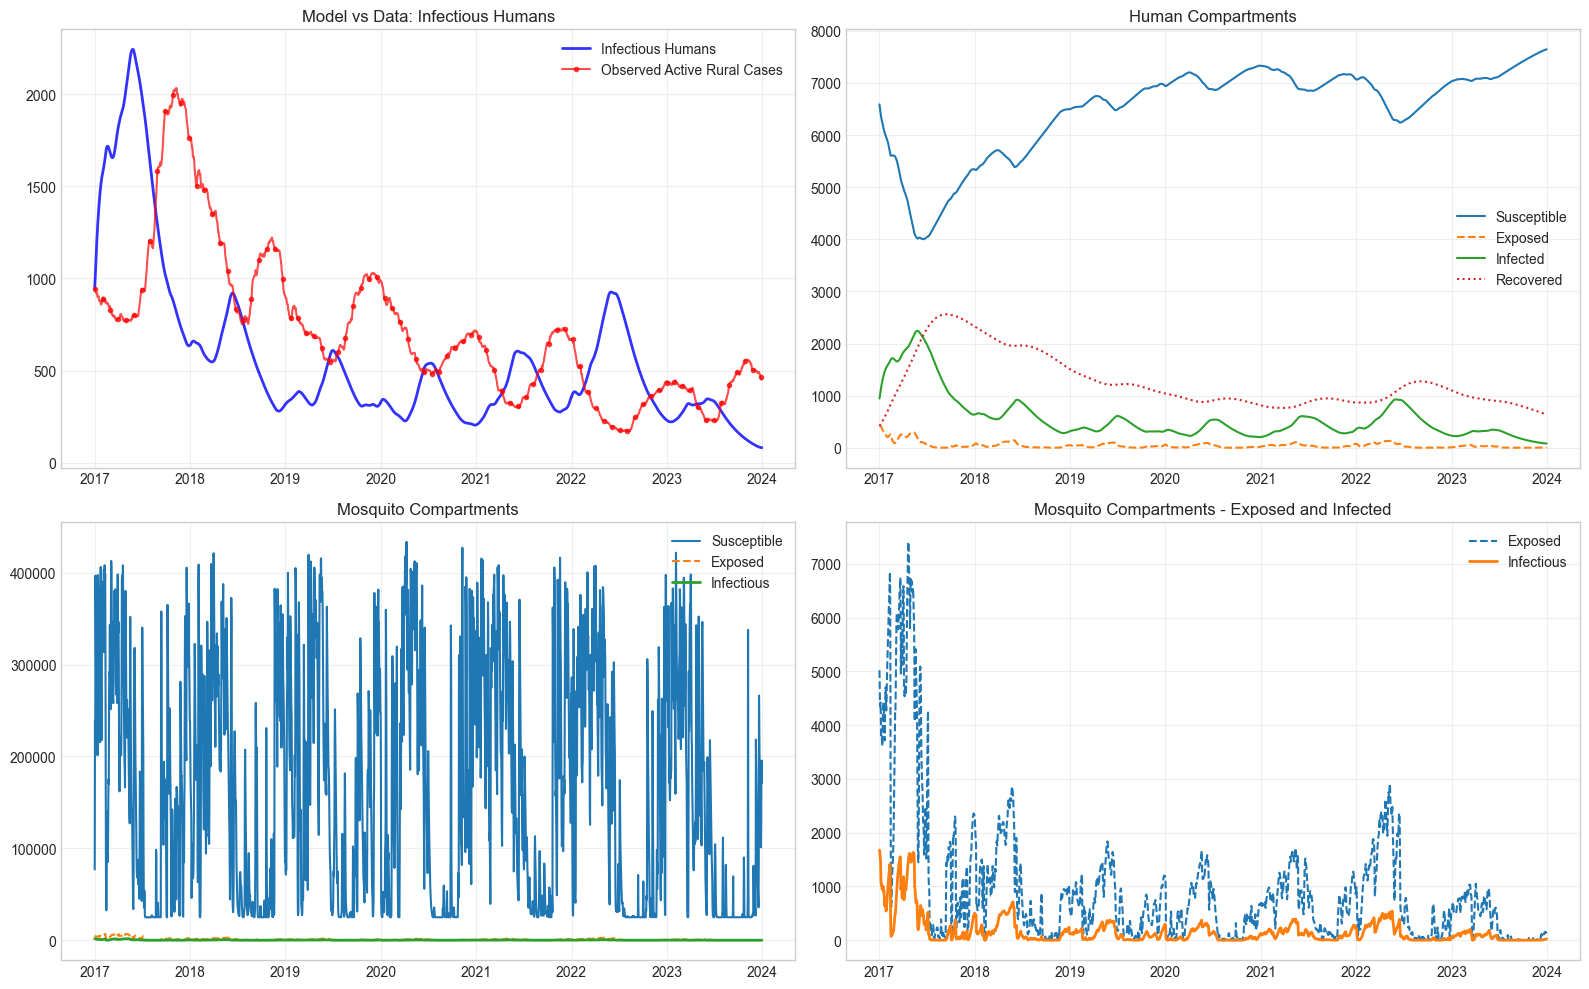

In [11]:
#### Combine and Plot Results
combined_df = pd.DataFrame()
for res in all_results:
    year = res['year']
    sol = res['sol']
    climate = res['climate']
    
    # Interpolate to daily resolution
    t_interp = np.linspace(0, sol.t[-1], len(climate))
    interp = [interp1d(sol.t, sol.y[i])(t_interp) for i in range(7)]
    
    df = pd.DataFrame({
        'date': pd.to_datetime(climate['date']).values,
        'S_H': interp[0], 'E_H': interp[1], 'I_H': interp[2], 'R_H': interp[3],
        'S_M': interp[4], 'E_M': interp[5], 'I_M': interp[6], 'N': res['N']
    })
    combined_df = pd.concat([combined_df, df]).reset_index(drop=True)

# Ensure date columns are datetime
combined_df['date'] = pd.to_datetime(combined_df['date'])
rural_cases_df['date'] = pd.to_datetime(rural_cases_df['date'])

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0,0].plot(combined_df['date'], combined_df['I_H'], 'b-', linewidth=2, label='Infectious Humans', alpha=0.8)
axes[0,0].plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.5, 
        label='Observed Active Rural Cases', alpha=0.7, marker='o', 
        markersize=3, markevery=30)  # Show markers every ~1 month for readability
axes[0,0].set_title('Model vs Data: Infectious Humans')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')
axes[0,1].set_title('Human Compartments'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(combined_df['date'], combined_df['S_M'], label='Susceptible', linewidth=1.5)
axes[1,0].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,0].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,0].set_title('Mosquito Compartments'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,1].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,1].set_title('Mosquito Compartments - Exposed and Infected'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

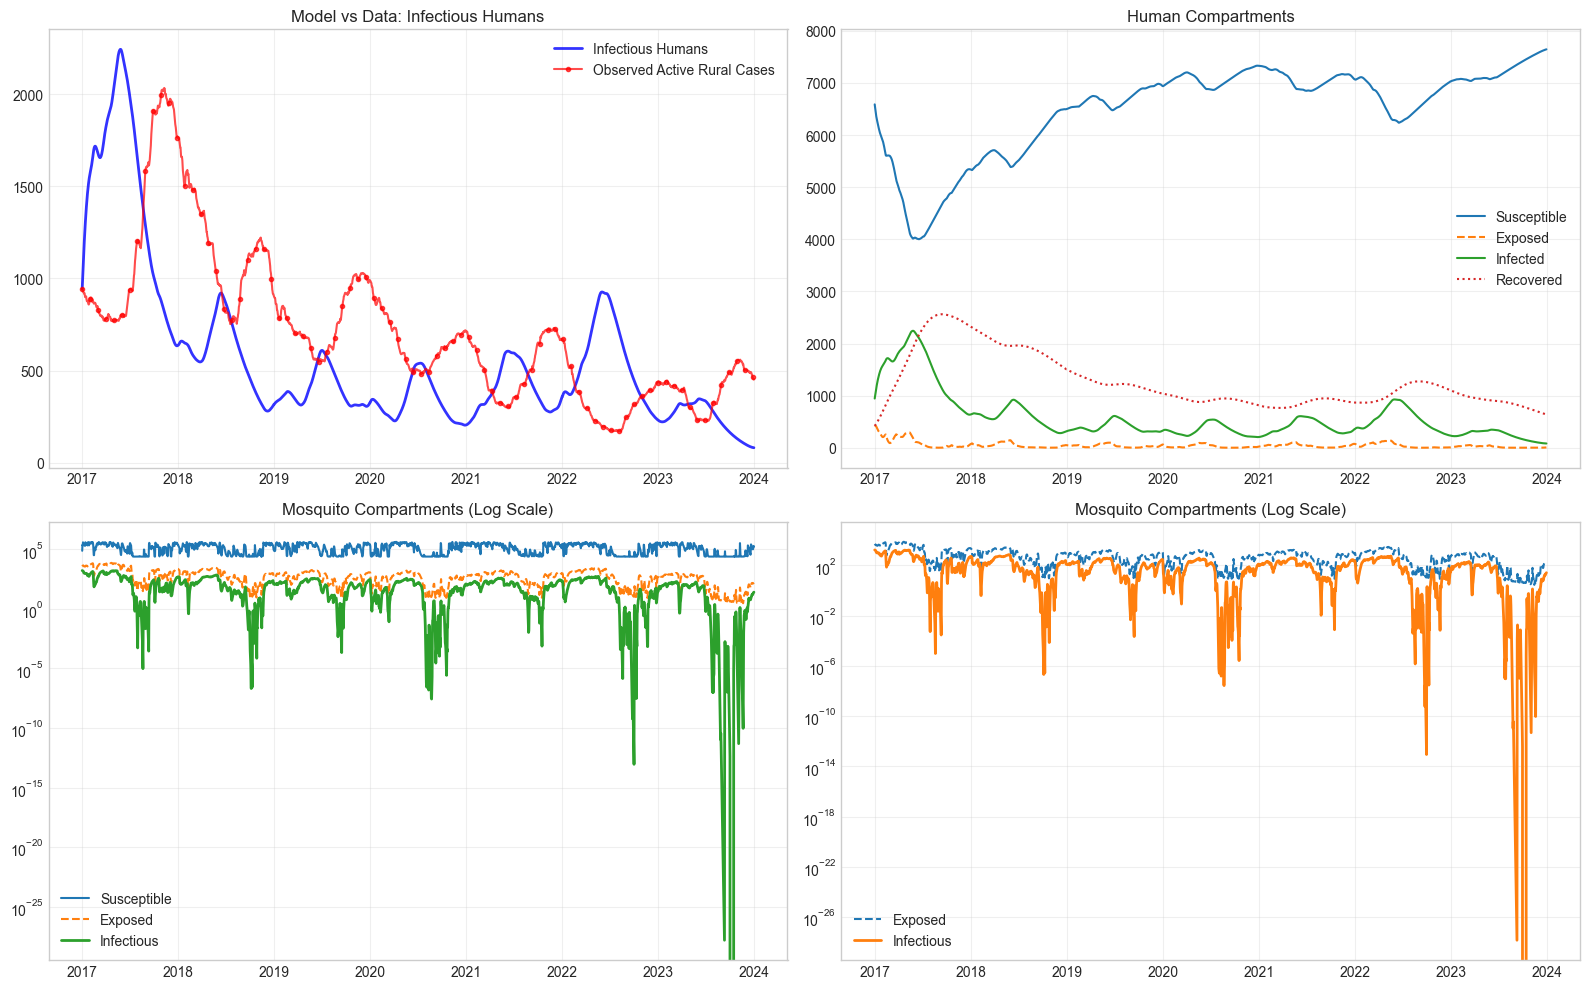

In [12]:
# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Infectious humans vs observed data
axes[0,0].plot(
    combined_df['date'],
    combined_df['I_H'],
    'b-',
    linewidth=2,
    label='Infectious Humans',
    alpha=0.8
)

axes[0,0].plot(
    rural_cases_df['date'],
    rural_cases_df['active_total'],
    'r-',
    linewidth=1.5,
    label='Observed Active Rural Cases',
    alpha=0.7,
    marker='o',
    markersize=3,
    markevery=30
)

axes[0,0].set_title('Model vs Data: Infectious Humans')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)


# Human compartments
axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')

axes[0,1].set_title('Human Compartments')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)


# Mosquito compartments (LOG SCALE)
axes[1,0].plot(
    combined_df['date'],
    combined_df['S_M'],
    label='Susceptible',
    linewidth=1.5
)

axes[1,0].plot(
    combined_df['date'],
    combined_df['E_M'],
    label='Exposed',
    linewidth=1.5,
    linestyle='--'
)

axes[1,0].plot(
    combined_df['date'],
    combined_df['I_M'],
    label='Infectious',
    linewidth=2
)

# Apply logarithmic scale
axes[1,0].set_yscale('log')
axes[1,0].set_title('Mosquito Compartments (Log Scale)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3, which='both')

axes[1,1].plot(
    combined_df['date'],
    combined_df['E_M'],
    label='Exposed',
    linewidth=1.5,
    linestyle='--'
)

axes[1,1].plot(
    combined_df['date'],
    combined_df['I_M'],
    label='Infectious',
    linewidth=2
)

# Apply logarithmic scale
axes[1,1].set_yscale('log')
axes[1,1].set_title('Mosquito Compartments (Log Scale)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

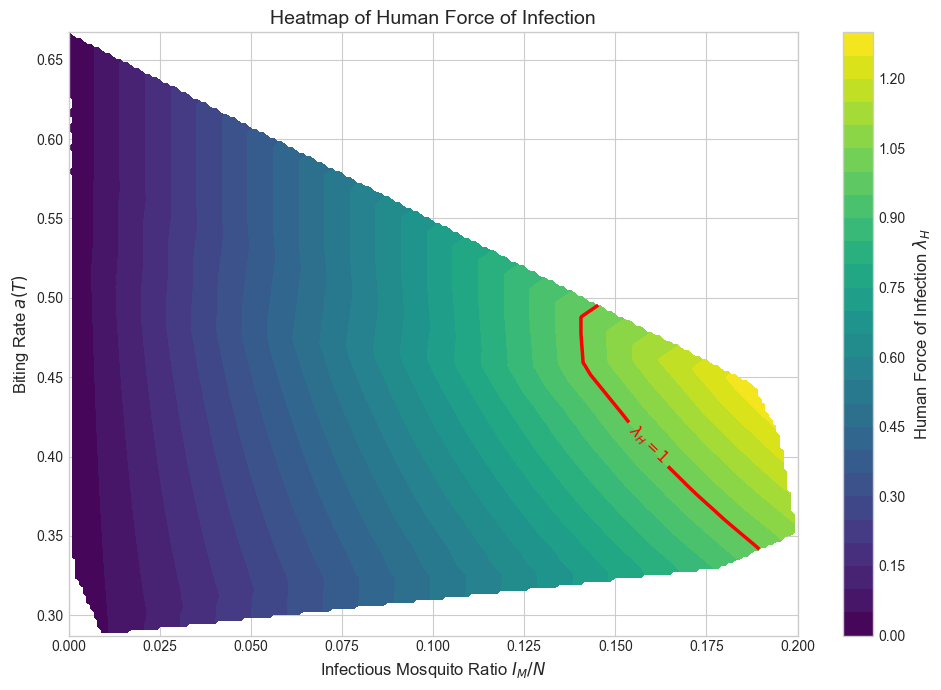

In [13]:
combined_df['Temp'] = climate_data['temp_med'].values[:len(combined_df)]

# Compute a(T) and b3(T)
combined_df['a_T'] = combined_df['Temp'].apply(a)
combined_df['b_3'] = combined_df['Temp'].apply(b3_briere_scaled_plasm)

# Infectious mosquito ratio
combined_df['IM_over_N'] = combined_df['I_M'] / combined_df['N']

# Human force of infection
combined_df['lambda_H'] = ((b2/combined_df['b_3'][0]) * 
    combined_df['a_T']
    * combined_df['IM_over_N']
    * combined_df['S_H'][0]/combined_df['E_H'][0]                       
)

# ============================================================
# Create grid for contourf
# ============================================================

x = combined_df['IM_over_N'].values
y = combined_df['a_T'].values
z = combined_df['lambda_H'].values

# Grid definition
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

Xi, Yi = np.meshgrid(xi, yi)

# Interpolate z values onto the grid
from scipy.interpolate import griddata

Zi = griddata(
    (x, y),
    z,
    (Xi, Yi),
    method='linear'
)

# ============================================================
# Plot contourf heatmap
# ============================================================

plt.figure(figsize=(10, 7))

contour = plt.contourf(
    Xi,
    Yi,
    Zi,
    levels=25,
    cmap='viridis'
)

critical_line = plt.contour(
    Xi,
    Yi,
    Zi,
    levels=[1],
    colors='red',
    linewidths=2.5
)

plt.clabel(
    critical_line,
    fmt={1: r'$\lambda_H = 1$'},
    fontsize=11
)

# Colorbar
cbar = plt.colorbar(contour)
cbar.set_label(r'Human Force of Infection $\lambda_H$', fontsize=12)

# Labels
plt.xlabel(r'Infectious Mosquito Ratio $I_M/N$', fontsize=12)
plt.ylabel(r'Biting Rate $a(T)$', fontsize=12)

plt.title(
    r'Heatmap of Human Force of Infection',
    fontsize=14
)

plt.tight_layout()
plt.show()

In [14]:
#### Yearly Simulation (2017-2023)
years = list(range(2017, 2024))
all_results = []
current_state = initial_state_2017.copy()

USE_SMOOTH_CLIMATE = True

for year in years:
    print(f"\nSimulating {year}...")
    N = round(pop_by_year[year])
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
    if USE_SMOOTH_CLIMATE:
        year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    num_days = len(year_climate)
    print(f"Year {year}: N={N}, Days={num_days}")
    
    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                            c1, c2, D1, b1, b2, A, B, C, DD, 
                            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                            gamma, R_L, M_prime, tau_H, omega,
                            M_min, permanent_factor, use_smooth_climate=USE_SMOOTH_CLIMATE)
    
    sol = solve_ivp(ode_func, [0, num_days], current_state, 
                    t_eval=np.linspace(0, num_days, num_days*10), method='LSODA') #'DOP853')
    
    all_results.append({'year': year, 'N': N, 'sol': sol, 'climate': year_climate})
    current_state = sol.y[:, -1].copy()
    print(f"Finished {year}. Final I_H: {round(current_state[2])}, Final I_M: {round(current_state[6])}")

print("\nAll years simulated successfully!")


Simulating 2017...
Year 2017: N=8369, Days=365
Finished 2017. Final I_H: 232, Final I_M: 32

Simulating 2018...
Year 2018: N=8260, Days=365
Finished 2018. Final I_H: 29, Final I_M: 5

Simulating 2019...
Year 2019: N=8153, Days=365
Finished 2019. Final I_H: 5, Final I_M: 1

Simulating 2020...
Year 2020: N=8045, Days=366
Finished 2020. Final I_H: 1, Final I_M: 0

Simulating 2021...
Year 2021: N=7939, Days=365
Finished 2021. Final I_H: 0, Final I_M: 0

Simulating 2022...
Year 2022: N=7832, Days=365
Finished 2022. Final I_H: 0, Final I_M: 0

Simulating 2023...
Year 2023: N=7942, Days=365
Finished 2023. Final I_H: 0, Final I_M: 0

All years simulated successfully!


In [15]:
def run_simulation_with_M(M_prime, initial_state=None):
    if initial_state is None:
        init_state = initial_state_2017.copy()
    else:
        init_state = initial_state.copy()
    all_IH = []
    all_dates = []
    current_state = init_state
    for year in years:
        N = round(pop_by_year[year])
        start = f"{year}-01-01"
        end = f"{year}-12-31"
        year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
        if USE_SMOOTH_CLIMATE:
            year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        num_days = len(year_climate)
        def ode_func(t, z):
            return seirs_sei_ode(t, z, N, year_climate,
                                T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                                c1, c2, D1, b1, b2, A, B, C, DD,
                                Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                                optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                                gamma, R_L, M_prime, tau_H, omega,
                                M_min=M_min, permanent_factor=permanent_factor, use_smooth_climate=USE_SMOOTH_CLIMATE)
        sol = solve_ivp(ode_func, [0, num_days], current_state,
                        t_eval=np.linspace(0, num_days, num_days*10), method='LSODA')
        if not sol.success:
            return np.array([]), np.array([])
        current_state = sol.y[:, -1].copy()
        current_state = np.maximum(current_state, 0)
        t_interp = np.linspace(0, sol.t[-1], len(year_climate))
        IH_interp = interp1d(sol.t, sol.y[2])(t_interp)
        all_IH.extend(IH_interp)
        all_dates.extend(year_climate['date'].values)
    return np.array(all_dates), np.array(all_IH)

In [16]:
def objective_function(log_M_prime):
    M_prime = np.exp(log_M_prime)
    # Use smoothed climate values to match ODE's carrying capacity calculation
    T0_smooth = climate_data['temp_med_smooth'].iloc[0]
    R0_smooth = climate_data['precip_med_smooth'].iloc[0]
    f_T_0 = temp_factor_briere_normalized_anop(T0_smooth)
    habitat_creating_factor_0 = 2*R0_smooth/R_L
    habitat_flushing_factor_0 = np.exp(1 - (2*R0_smooth/R_L))
    f_R_0 = habitat_creating_factor_0 * habitat_flushing_factor_0
    K_0 = M_prime * f_T_0 * f_R_0
    if M_0 > K_0:
        return 1e15
    dates, IH = run_simulation_with_M(M_prime)
    if len(dates) == 0:
        return 1e15
    model_interp = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    obs_dates_int = rural_cases_df['date'].astype(np.int64).values
    model_at_obs = model_interp(obs_dates_int)
    observed = rural_cases_df['active_total'].values
    mse = np.mean((model_at_obs - observed) ** 2)
    return mse

In [17]:
print("Grid search for M'...")
multipliers = [10, 20, 30, 40, 50, 60, 75] #[10, 20, 30, 50, 75, 100, 150, 200, 300, 500] #Reduces ranges of multiplier for faster solving
grid_results = []
for mult in multipliers:
    M_prime_test = mult * N_2017
    log_mp = np.log(M_prime_test)
    mse = objective_function(log_mp)
    grid_results.append((M_prime_test, mult, mse))
    print(f"  M' = {mult:>4d} x N = {M_prime_test:>12,.0f} -> MSE = {mse:>15,.2f}")
grid_results.sort(key=lambda x: x[2])
best_mult = grid_results[0][1]
best_mse = grid_results[0][2]
print(f"\nBest from grid: M' = {best_mult} x N (MSE = {best_mse:,.2f})")

Grid search for M'...
  M' =   10 x N =       83,690 -> MSE = 1,000,000,000,000,000.00
  M' =   20 x N =      167,380 -> MSE =      490,119.52
  M' =   30 x N =      251,070 -> MSE =      440,866.14
  M' =   40 x N =      334,760 -> MSE =      373,761.90
  M' =   50 x N =      418,450 -> MSE =      377,143.44
  M' =   60 x N =      502,140 -> MSE =      547,945.14
  M' =   75 x N =      627,675 -> MSE =      900,481.08

Best from grid: M' = 40 x N (MSE = 373,761.90)


In [18]:
print("Fine optimization with minimize_scalar...")
log_low = np.log(best_mult * 0.3 * N_2017)
log_high = np.log(best_mult * 3.0 * N_2017)
result = minimize_scalar(
    objective_function,
    bounds=(log_low, log_high),
    method='bounded',
    options={'maxiter': 100, 'xatol': 0.01}
)
M_prime_optimal = np.exp(result.x)
optimal_multiplier = M_prime_optimal / N_2017
print(f"Optimal M' = {optimal_multiplier:.2f} x N = {M_prime_optimal:,.0f}")
print(f"Optimal MSE = {result.fun:,.2f}")

Fine optimization with minimize_scalar...
Optimal M' = 44.86 x N = 375,455
Optimal MSE = 353,280.76


Final simulation with optimal M'...


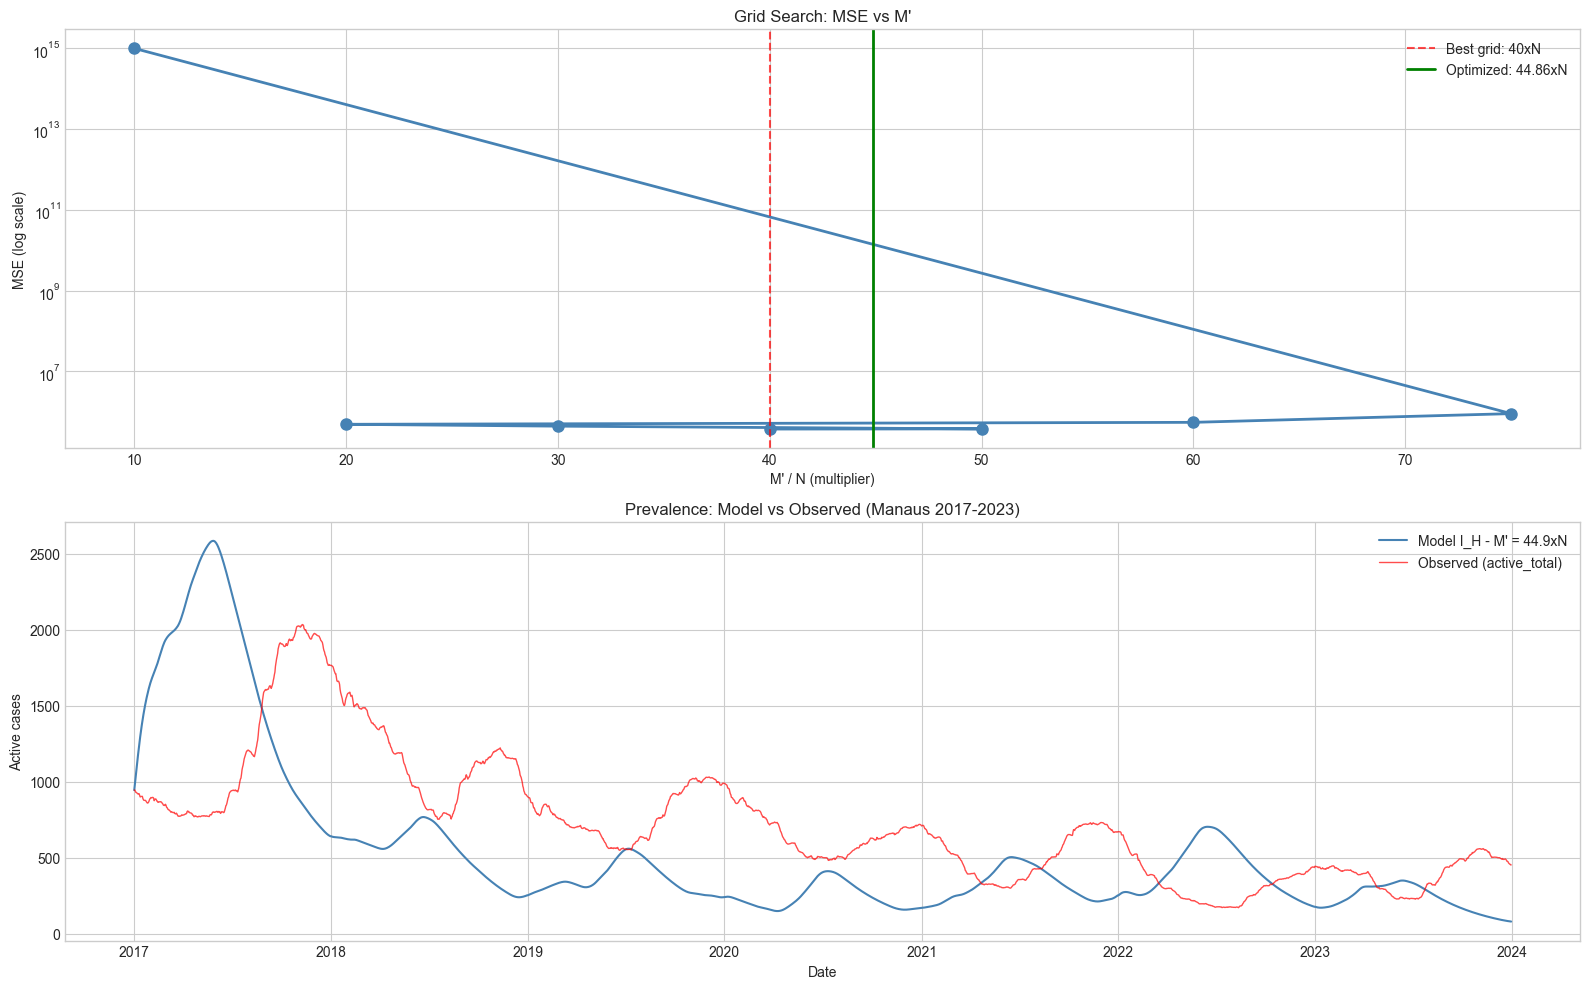


Calibration Summary
  Population N (2017):                8,369
  M_0 initial (9.9 x N):            83,690
  Optimal M':                      375,455
  Optimal M' / N:                    44.86
  Final MSE:                         353,280.76
  Final RMSE:                            594.37


In [19]:
print("Final simulation with optimal M'...")
dates_opt, IH_opt = run_simulation_with_M(M_prime_optimal)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax1 = axes[0]
mults = [r[1] for r in grid_results]
mses = [r[2] for r in grid_results]
ax1.semilogy(mults, mses, 'o-', color='steelblue', markersize=8, linewidth=2)
ax1.axvline(best_mult, color='red', linestyle='--', alpha=0.7, label=f'Best grid: {best_mult}xN')
ax1.axvline(optimal_multiplier, color='green', linestyle='-', linewidth=2,
            label=f"Optimized: {optimal_multiplier:.2f}xN")
ax1.set_xlabel("M' / N (multiplier)")
ax1.set_ylabel("MSE (log scale)")
ax1.set_title("Grid Search: MSE vs M'")
ax1.legend()

ax2 = axes[1]
ax2.plot(pd.to_datetime(dates_opt), IH_opt, color='steelblue',
         linewidth=1.5, label=f"Model I_H - M' = {optimal_multiplier:.1f}xN")
ax2.plot(rural_cases_df['date'], rural_cases_df['active_total'], color='red',
         linewidth=1.0, alpha=0.7, label='Observed (active_total)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Active cases')
ax2.set_title('Prevalence: Model vs Observed (Manaus 2017-2023)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nCalibration Summary")
print(f"  Population N (2017):           {N_2017:>10,}")
print(f"  M_0 initial (9.9 x N):        {M_0:>10,.0f}")
print(f"  Optimal M':                   {M_prime_optimal:>10,.0f}")
print(f"  Optimal M' / N:               {optimal_multiplier:>10.2f}")
print(f"  Final MSE:                    {result.fun:>15,.2f}")
print(f"  Final RMSE:                   {np.sqrt(result.fun):>15,.2f}")

In [20]:
#### Yearly Simulation (2017-2023)
years = list(range(2017, 2024))
all_results = []
current_state = initial_state_2017.copy()

for year in years:
    print(f"\nSimulating {year}...")
    N = round(pop_by_year[year])
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
    if USE_SMOOTH_CLIMATE:
        year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    num_days = len(year_climate)
    print(f"Year {year}: N={N}, Days={num_days}")
    
    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                            c1, c2, D1, b1, b2, A, B, C, DD, 
                            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                            gamma, R_L, M_prime_optimal, tau_H, omega,
                            M_min=M_min, permanent_factor=permanent_factor, use_smooth_climate=USE_SMOOTH_CLIMATE)
    
    sol = solve_ivp(ode_func, [0, num_days], current_state, 
                    t_eval=np.linspace(0, num_days, num_days*10), method='LSODA') #'DOP853')
    
    all_results.append({'year': year, 'N': N, 'sol': sol, 'climate': year_climate})
    current_state = sol.y[:, -1].copy()
    print(f"Finished {year}. Final I_H: {round(current_state[2])}, Final I_M: {round(current_state[6])}")

print("\nAll years simulated successfully!")


Simulating 2017...
Year 2017: N=8369, Days=365
Finished 2017. Final I_H: 640, Final I_M: 305

Simulating 2018...
Year 2018: N=8260, Days=365
Finished 2018. Final I_H: 252, Final I_M: 152

Simulating 2019...
Year 2019: N=8153, Days=365
Finished 2019. Final I_H: 240, Final I_M: 139

Simulating 2020...
Year 2020: N=8045, Days=366
Finished 2020. Final I_H: 168, Final I_M: 76

Simulating 2021...
Year 2021: N=7939, Days=365
Finished 2021. Final I_H: 251, Final I_M: 161

Simulating 2022...
Year 2022: N=7832, Days=365
Finished 2022. Final I_H: 176, Final I_M: 27

Simulating 2023...
Year 2023: N=7942, Days=365
Finished 2023. Final I_H: 79, Final I_M: 10

All years simulated successfully!


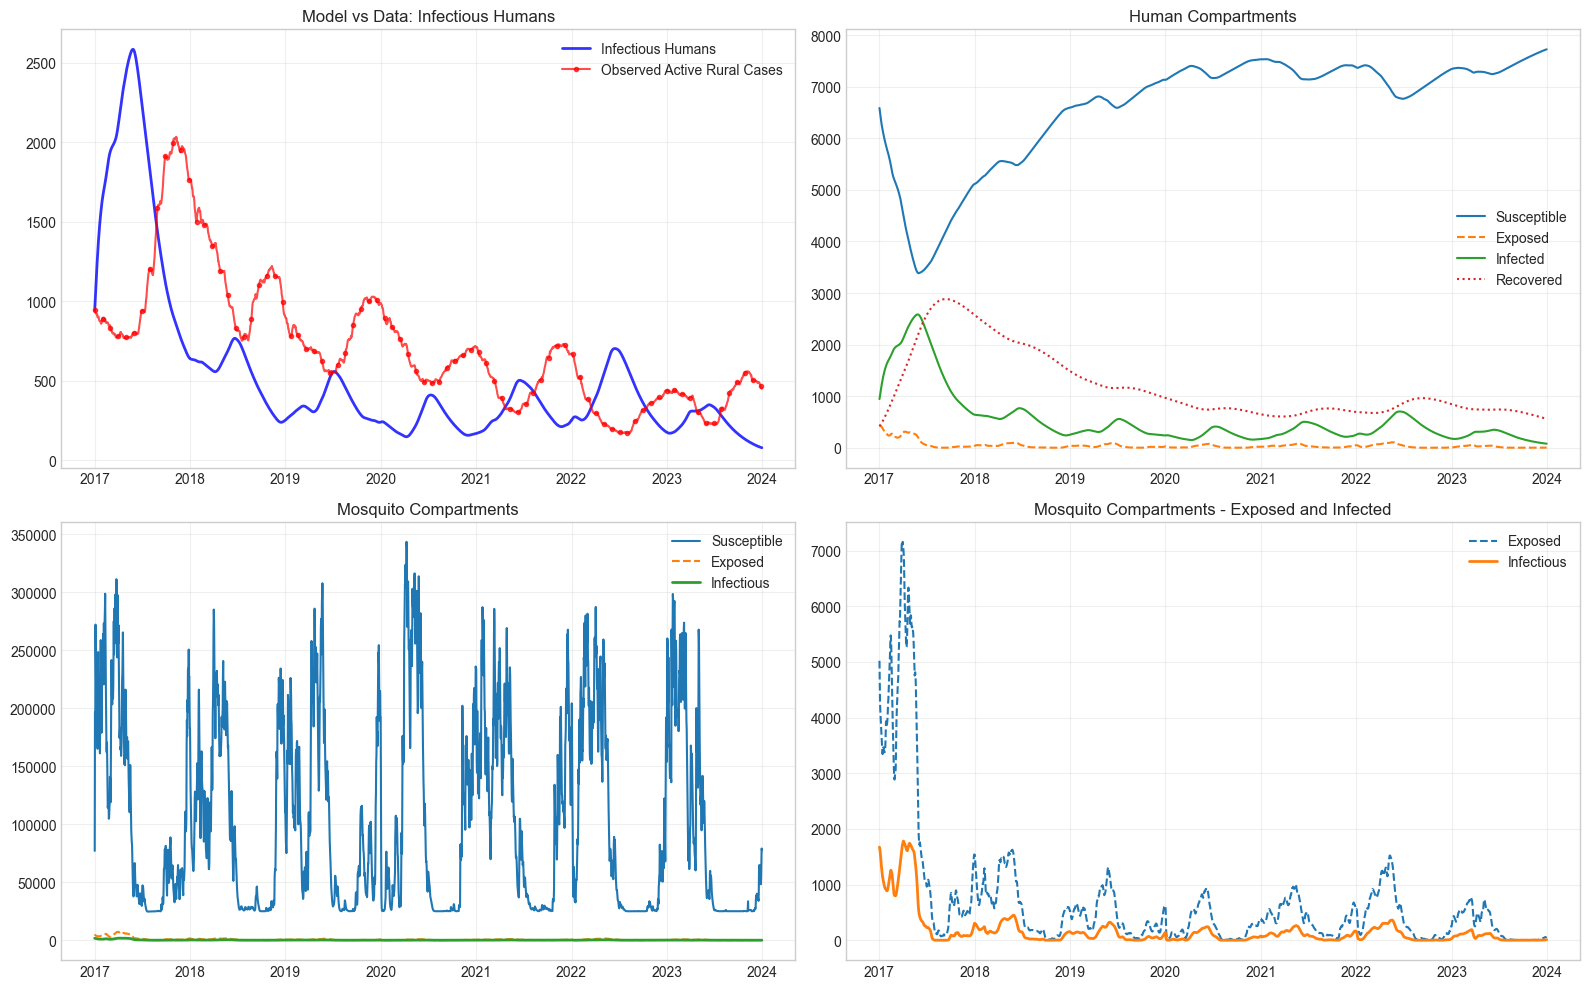

In [21]:
#### Combine and Plot Results
combined_df = pd.DataFrame()
for res in all_results:
    year = res['year']
    sol = res['sol']
    climate = res['climate']
    
    # Interpolate to daily resolution
    t_interp = np.linspace(0, sol.t[-1], len(climate))
    interp = [interp1d(sol.t, sol.y[i])(t_interp) for i in range(7)]
    
    df = pd.DataFrame({
        'date': pd.to_datetime(climate['date']).values,
        'S_H': interp[0], 'E_H': interp[1], 'I_H': interp[2], 'R_H': interp[3],
        'S_M': interp[4], 'E_M': interp[5], 'I_M': interp[6], 'N': res['N']
    })
    combined_df = pd.concat([combined_df, df]).reset_index(drop=True)

# Ensure date columns are datetime
combined_df['date'] = pd.to_datetime(combined_df['date'])
rural_cases_df['date'] = pd.to_datetime(rural_cases_df['date'])

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0,0].plot(combined_df['date'], combined_df['I_H'], 'b-', linewidth=2, label='Infectious Humans', alpha=0.8)
axes[0,0].plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.5, 
        label='Observed Active Rural Cases', alpha=0.7, marker='o', 
        markersize=3, markevery=30)  # Show markers every ~1 month for readability
axes[0,0].set_title('Model vs Data: Infectious Humans')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')
axes[0,1].set_title('Human Compartments'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(combined_df['date'], combined_df['S_M'], label='Susceptible', linewidth=1.5)
axes[1,0].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,0].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,0].set_title('Mosquito Compartments'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,1].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,1].set_title('Mosquito Compartments - Exposed and Infected'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

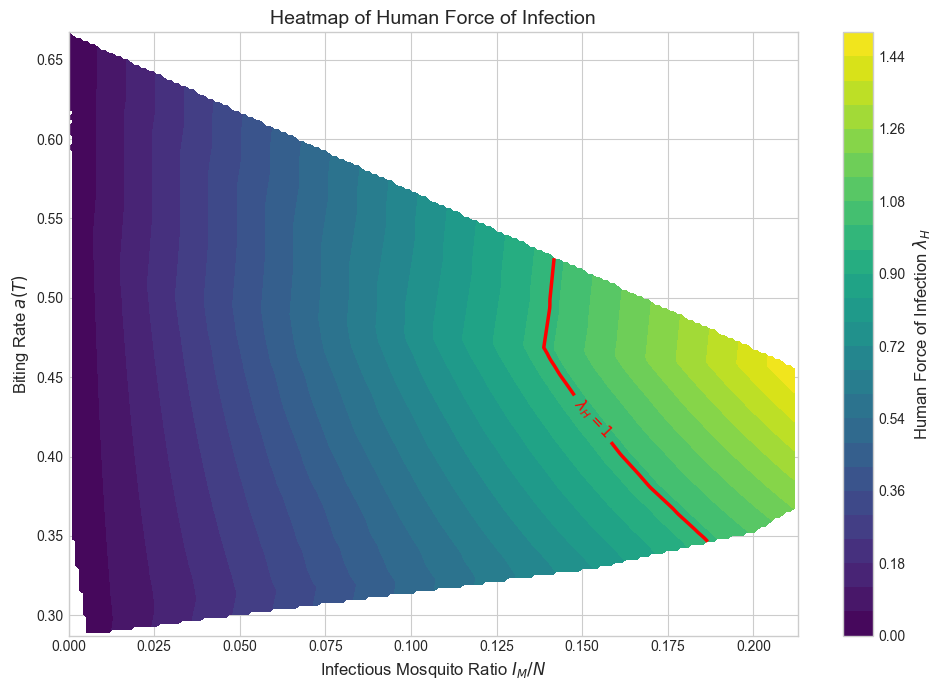

In [22]:
combined_df['Temp'] = climate_data['temp_med'].values[:len(combined_df)]

# Compute a(T) and b3(T)
combined_df['a_T'] = combined_df['Temp'].apply(a)
combined_df['b_3'] = combined_df['Temp'].apply(b3_briere_scaled_plasm)

# Infectious mosquito ratio
combined_df['IM_over_N'] = combined_df['I_M'] / combined_df['N']

# Human force of infection
combined_df['lambda_H'] = ((b2/combined_df['b_3'][0]) * 
    combined_df['a_T']
    * combined_df['IM_over_N']
    * combined_df['S_H'][0]/combined_df['E_H'][0]                       
)

# ============================================================
# Create grid for contourf
# ============================================================

x = combined_df['IM_over_N'].values
y = combined_df['a_T'].values
z = combined_df['lambda_H'].values

# Grid definition
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

Xi, Yi = np.meshgrid(xi, yi)

# Interpolate z values onto the grid
from scipy.interpolate import griddata

Zi = griddata(
    (x, y),
    z,
    (Xi, Yi),
    method='linear'
)

# ============================================================
# Plot contourf heatmap
# ============================================================

plt.figure(figsize=(10, 7))

contour = plt.contourf(
    Xi,
    Yi,
    Zi,
    levels=25,
    cmap='viridis'
)

critical_line = plt.contour(
    Xi,
    Yi,
    Zi,
    levels=[1],
    colors='red',
    linewidths=2.5
)

plt.clabel(
    critical_line,
    fmt={1: r'$\lambda_H = 1$'},
    fontsize=11
)

# Colorbar
cbar = plt.colorbar(contour)
cbar.set_label(r'Human Force of Infection $\lambda_H$', fontsize=12)

# Labels
plt.xlabel(r'Infectious Mosquito Ratio $I_M/N$', fontsize=12)
plt.ylabel(r'Biting Rate $a(T)$', fontsize=12)

plt.title(
    r'Heatmap of Human Force of Infection',
    fontsize=14
)

plt.tight_layout()
plt.show()